## Task 1: Dataset Preparation

### 1. Load the CIFAR-10 dataset using TensorFlow/Keras.

In [23]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("CIFAR-10 dataset loaded successfully.")

CIFAR-10 dataset loaded successfully.


In [47]:
import os

plot_dir = 'mandatory_plots'
os.makedirs(plot_dir, exist_ok=True)
print(f"Directory '{plot_dir}' created or already exists.")

Directory 'mandatory_plots' created or already exists.


### 2. Normalize the pixel values to the range [0,1].

In [24]:
# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Pixel values normalized to [0, 1].")

Pixel values normalized to [0, 1].


### 3. Display ten sample images.

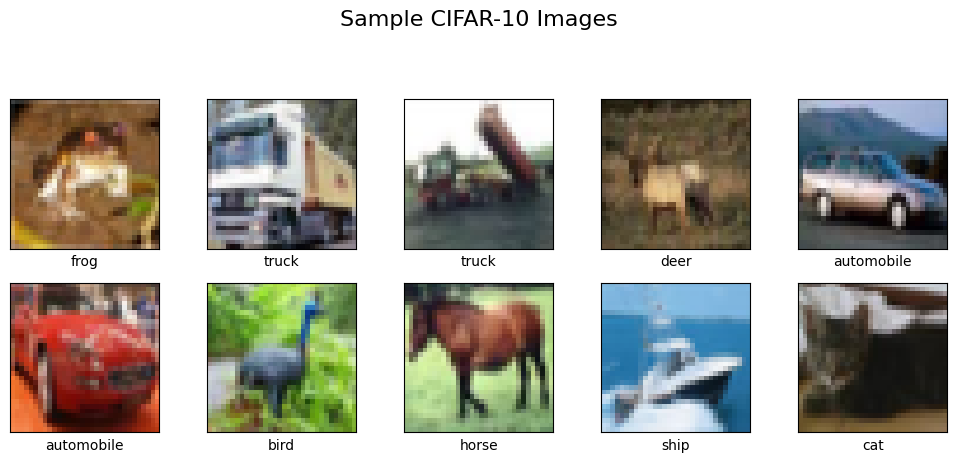

In [48]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 10))
for i in range(10):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    # The CIFAR-10 labels are arrays, so you need the first index
    plt.xlabel(class_names[y_train[i][0]])
plt.suptitle('Sample CIFAR-10 Images', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.savefig(os.path.join(plot_dir, 'sample_cifar10_images.png'))
plt.show()

### 4. Print the dimensions of the training and testing datasets.

In [26]:
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing data shape: {x_test.shape}")
print(f"Testing labels shape: {y_test.shape}")

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


## Task 2: Transfer Learning

For transfer learning, we will load a pre-trained CNN model (e.g., VGG16), remove its original classification layer, freeze its convolutional base, and then add custom layers for the CIFAR-10 classification task.

### 1. Load pretrained ImageNet weights & 2. Remove the original classification layer & 3. Freeze the convolutional base.

In [27]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Define input shape for CIFAR-10 images
IMG_SHAPE = (32, 32, 3)
NUM_CLASSES = 10

# Load the VGG16 model with pre-trained ImageNet weights
# exclude the top (classification) layer
base_model = VGG16(input_shape=IMG_SHAPE,
                   include_top=False,
                   weights='imagenet')

# Freeze the convolutional base
base_model.trainable = False

print("VGG16 base model loaded and convolutional base frozen.")

VGG16 base model loaded and convolutional base frozen.


### 4. Add a Global Average Pooling layer.

In [28]:
# Add a Global Average Pooling layer
x = base_model.output
x = GlobalAveragePooling2D()(x)

print("Global Average Pooling layer added.")

Global Average Pooling layer added.


### 5. Add a Dense layer with ReLU activation.

In [29]:
# Add a Dense layer with ReLU activation
x = Dense(256, activation='relu')(x)

print("Dense layer with ReLU activation added.")

Dense layer with ReLU activation added.


### 6. Add the output layer with Softmax activation.

In [30]:
# Add the output layer with Softmax activation
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

model.summary()
print("Output layer with Softmax activation added and model compiled.")

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Output layer with Softmax activation added and model compiled.


## Task 3: Model Training

In [31]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss=SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

print("Model compiled successfully with Adam optimizer, SparseCategoricalCrossentropy loss, and Accuracy metric.")

Model compiled successfully with Adam optimizer, SparseCategoricalCrossentropy loss, and Accuracy metric.


### Train the model

In [32]:
# Train the model
# Convert labels to one-hot encoding if using CategoricalCrossentropy, otherwise SparseCategoricalCrossentropy is fine.
# Since y_train/y_test are (N, 1), SparseCategoricalCrossentropy is appropriate.
history = model.fit(x_train, y_train,
                    epochs=10, # As per task, 10-20 epochs
                    batch_size=32, # As per task, 32
                    validation_data=(x_test, y_test))

print("Model training complete.")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.5304 - loss: 1.3467 - val_accuracy: 0.5542 - val_loss: 1.2693
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.5900 - loss: 1.1707 - val_accuracy: 0.5835 - val_loss: 1.1760
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6111 - loss: 1.1092 - val_accuracy: 0.5837 - val_loss: 1.1778
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6305 - loss: 1.0575 - val_accuracy: 0.5966 - val_loss: 1.1569
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6437 - loss: 1.0141 - val_accuracy: 0.6040 - val_loss: 1.1305
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6569 - loss: 0.9785 - val_accuracy: 0.6119 - val_loss: 1.1156
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6694 - loss: 0.9414 - val_accuracy: 0.6153 - val_loss: 1.1047
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6808 - loss:

## Task 4: Fine Tuning

### 1. Unfreeze the last convolution block.

In [33]:
# Unfreeze the last convolution block
# Iterate through the layers of the base model in reverse order
# and unfreeze the last block. VGG16 has 5 blocks.

# Let's count the number of blocks/layers to identify the 'last convolution block'
# VGG16 typically has 5 convolutional blocks. We need to find the layers within the last block.
# A common approach is to unfreeze a certain percentage of the top layers or specific blocks.

# For VGG16, block5_conv1, block5_conv2, block5_conv3 are the layers in the last block.

base_model.trainable = True

# Set all layers to trainable False again
for layer in base_model.layers:
    layer.trainable = False

# Then unfreeze only the layers in the last block (block5 in VGG16)
for layer in base_model.layers[-4:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# Display which layers are trainable
print("Layers in the base model after unfreezing:")
for layer in base_model.layers:
    print(f"{layer.name}: {layer.trainable}")

print("Last convolution block unfrozen.")

Layers in the base model after unfreezing:
input_layer_5: False
block1_conv1: False
block1_conv2: False
block1_pool: False
block2_conv1: False
block2_conv2: False
block2_pool: False
block3_conv1: False
block3_conv2: False
block3_conv3: False
block3_pool: False
block4_conv1: False
block4_conv2: False
block4_conv3: False
block4_pool: False
block5_conv1: True
block5_conv2: True
block5_conv3: True
block5_pool: True
Last convolution block unfrozen.


### Recompile the model after unfreezing layers

In [34]:
# It's important to recompile the model after modifying trainable layers
model.compile(optimizer=Adam(learning_rate=0.0001), # Often a smaller learning rate is used for fine-tuning
              loss=SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model.summary()
print("Model recompiled for fine-tuning.")

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Model recompiled for fine-tuning.


### 2. Train for another 5–10 epochs.

In [35]:
# Train the model for additional epochs (fine-tuning)
history_fine_tune = model.fit(x_train, y_train,
                                 epochs=5, # As per task, 5-10 additional epochs
                                 batch_size=32,
                                 validation_data=(x_test, y_test))

print("Model fine-tuning complete.")

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.6494 - loss: 1.0038 - val_accuracy: 0.6929 - val_loss: 0.8773
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7309 - loss: 0.7645 - val_accuracy: 0.7164 - val_loss: 0.8319
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7760 - loss: 0.6321 - val_accuracy: 0.7190 - val_loss: 0.8284
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8132 - loss: 0.5158 - val_accuracy: 0.7301 - val_loss: 0.8237
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8526 - loss: 0.4112 - val_accuracy: 0.7217 - val_loss: 0.8814
Model fine-tuning complete.


### 3. Compare the classification accuracy before and after fine tuning.

In [36]:
print("Accuracy before fine-tuning (last epoch of initial training):")
print(f"Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

print("\nAccuracy after fine-tuning (last epoch of fine-tuning):")
print(f"Training Accuracy: {history_fine_tune.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history_fine_tune.history['val_accuracy'][-1]:.4f}")

Accuracy before fine-tuning (last epoch of initial training):
Training Accuracy: 0.7017
Validation Accuracy: 0.6217

Accuracy after fine-tuning (last epoch of fine-tuning):
Training Accuracy: 0.8526
Validation Accuracy: 0.7217


## Task 5: Model Evaluation

Test Loss: 0.8814
Test Accuracy: 0.7217
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

Classification Report:
              precision    recall  f1-score   support

    airplane       0.78      0.81      0.80      1000
  automobile       0.72      0.92      0.81      1000
        bird       0.83      0.58      0.68      1000
         cat       0.51      0.61      0.56      1000
        deer       0.63      0.70      0.66      1000
         dog       0.72      0.52      0.60      1000
        frog       0.73      0.80      0.77      1000
       horse       0.69      0.86      0.77      1000
        ship       0.86      0.83      0.84      1000
       truck       0.93      0.57      0.71      1000

    accuracy                           0.72     10000
   macro avg       0.74      0.72      0.72     10000
weighted avg       0.74      0.72      0.72     10000



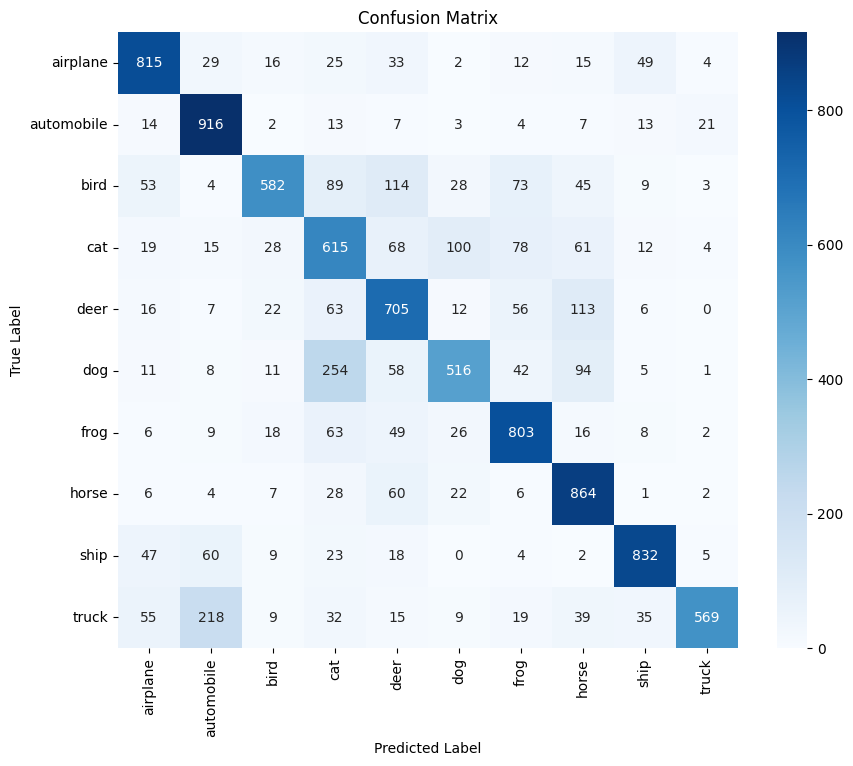

Model evaluation complete with Accuracy, Precision, Recall, F1-score, and Confusion Matrix.


In [49]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Evaluate the model on the test set
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Get predictions for the test set
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Since y_test is (N, 1), convert it to (N,) for classification_report and confusion_matrix
y_test_flat = y_test.flatten()

# Classification Report
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print("\nClassification Report:")
print(classification_report(y_test_flat, y_pred, target_names=class_names))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_flat, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig(os.path.join(plot_dir, 'confusion_matrix.png'))
plt.show()

print("Model evaluation complete with Accuracy, Precision, Recall, F1-score, and Confusion Matrix.")

## 16. Hyperparameter Study

To perform a hyperparameter study, we need to systematically vary the given hyperparameters and evaluate the model's performance for each combination. The hyperparameters to study are:

*   **Learning Rate**: 0.001, 0.0001
*   **Batch Size**: 16, 32, 64
*   **Epochs**: 10, 20
*   **Optimizer**: Adam, SGD
*   **Dense Units**: 128, 256
*   **Frozen Layers**: All, Partial

Due to the computational cost of training many models, we will demonstrate a study for a subset of these hyperparameters. We'll focus on `Learning Rate` and `Dense Units` first, using the VGG16 base model with frozen convolutional layers, and then train for a fixed number of epochs. For a comprehensive study, you would typically use techniques like Grid Search or Random Search.

### Hyperparameter Study: Learning Rate and Dense Units

We will define a function to create and compile a new model for each set of hyperparameters to ensure a clean slate for each experiment. We'll then iterate through combinations of learning rates and dense units.

In [38]:
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16

# Helper function to create and compile a new model for each experiment
def create_new_model(learning_rate, dense_units, optimizer_type='Adam', frozen_layers_config='All'):
    # Re-initialize base_model to ensure a fresh state if 'All' frozen_layers_config
    # For simplicity, we'll keep the VGG16 base model as is (32x32x3 input)
    IMG_SHAPE = (32, 32, 3)
    NUM_CLASSES = 10

    # Load the VGG16 model with pre-trained ImageNet weights
    # exclude the top (classification) layer
    base_model_exp = VGG16(input_shape=IMG_SHAPE,
                           include_top=False,
                           weights='imagenet')

    if frozen_layers_config == 'All':
        base_model_exp.trainable = False
    elif frozen_layers_config == 'Partial':
        # Unfreeze the last convolution block (block5 in VGG16) for partial fine-tuning
        base_model_exp.trainable = True
        for layer in base_model_exp.layers:
            layer.trainable = False
        for layer in base_model_exp.layers[-4:]:
            if not isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = True

    x = base_model_exp.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(dense_units, activation='relu')(x) # Use specified dense_units
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)

    model_exp = Model(inputs=base_model_exp.input, outputs=predictions)

    # Select optimizer
    if optimizer_type == 'Adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_type == 'SGD':
        optimizer = SGD(learning_rate=learning_rate)
    else:
        raise ValueError("Unsupported optimizer_type")

    model_exp.compile(optimizer=optimizer,
                      loss=SparseCategoricalCrossentropy(from_logits=False),
                      metrics=['accuracy'])

    return model_exp

# Hyperparameter values to explore (a subset for demonstration)
learning_rates = [0.001, 0.0001]
dense_units_options = [128, 256]

results = []

# Note: To perform a more complete study, you would need to iterate through all combinations
# of batch_size, epochs, optimizer, and frozen_layers, calling create_new_model accordingly.
# This can be very time-consuming, especially for VGG16 on CIFAR-10.

### Experiment 1: Learning Rate = 0.001, Dense Units = 128

In [18]:
lr = learning_rates[0]
du = dense_units_options[0]

print(f"\n--- Running experiment with Learning Rate: {lr}, Dense Units: {du} ---")
model_experiment_1 = create_new_model(lr, du, optimizer_type='Adam', frozen_layers_config='All')

# Train the model
history_exp_1 = model_experiment_1.fit(x_train, y_train,
                                           epochs=10,
                                           batch_size=32,
                                           validation_data=(x_test, y_test),
                                           verbose=1)

# Evaluate the model
loss_exp_1, accuracy_exp_1 = model_experiment_1.evaluate(x_test, y_test, verbose=0)

results.append({
    'learning_rate': lr,
    'dense_units': du,
    'optimizer': 'Adam',
    'frozen_layers': 'All',
    'final_val_accuracy': history_exp_1.history['val_accuracy'][-1],
    'test_accuracy': accuracy_exp_1,
    'test_loss': loss_exp_1
})

print(f"Experiment finished. Validation Accuracy: {history_exp_1.history['val_accuracy'][-1]:.4f}, Test Accuracy: {accuracy_exp_1:.4f}")


--- Running experiment with Learning Rate: 0.001, Dense Units: 128 ---
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.5194 - loss: 1.3769 - val_accuracy: 0.5571 - val_loss: 1.2591
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5845 - loss: 1.1965 - val_accuracy: 0.5720 - val_loss: 1.2161
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6012 - loss: 1.1418 - val_accuracy: 0.5864 - val_loss: 1.1881
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6149 - loss: 1.1029 - val_accuracy: 0.5957 - val_loss: 1.1527
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6277 - loss: 1.0703 - val_accuracy: 0.6014 - val_loss: 1.1463
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6345 - loss: 1.0434 - val_accuracy: 0.6027 - val_loss: 1.1354
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6445 - loss: 1.0160 - val_accuracy: 0.5971 - val_loss: 1.1486
Epoch 8/10

### Experiment 2: Learning Rate = 0.001, Dense Units = 256

In [19]:
lr = learning_rates[0]
du = dense_units_options[1]

print(f"\n--- Running experiment with Learning Rate: {lr}, Dense Units: {du} ---")
model_experiment_2 = create_new_model(lr, du, optimizer_type='Adam', frozen_layers_config='All')

# Train the model
history_exp_2 = model_experiment_2.fit(x_train, y_train,
                                           epochs=10,
                                           batch_size=32,
                                           validation_data=(x_test, y_test),
                                           verbose=1)

# Evaluate the model
loss_exp_2, accuracy_exp_2 = model_experiment_2.evaluate(x_test, y_test, verbose=0)

results.append({
    'learning_rate': lr,
    'dense_units': du,
    'optimizer': 'Adam',
    'frozen_layers': 'All',
    'final_val_accuracy': history_exp_2.history['val_accuracy'][-1],
    'test_accuracy': accuracy_exp_2,
    'test_loss': loss_exp_2
})

print(f"Experiment finished. Validation Accuracy: {history_exp_2.history['val_accuracy'][-1]:.4f}, Test Accuracy: {accuracy_exp_2:.4f}")


--- Running experiment with Learning Rate: 0.001, Dense Units: 256 ---
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.5316 - loss: 1.3427 - val_accuracy: 0.5623 - val_loss: 1.2282
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5919 - loss: 1.1671 - val_accuracy: 0.5833 - val_loss: 1.1890
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6125 - loss: 1.0996 - val_accuracy: 0.5908 - val_loss: 1.1641
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6296 - loss: 1.0503 - val_accuracy: 0.6026 - val_loss: 1.1367
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6440 - loss: 1.0081 - val_accuracy: 0.6046 - val_loss: 1.1373
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6595 - loss: 0.9717 - val_accuracy: 0.6118 - val_loss: 1.1141
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6702 - loss: 0.9366 - val_accuracy: 0.6150 - val_loss: 1.1187
Epoch 8/10

### Experiment 3: Learning Rate = 0.0001, Dense Units = 128

In [20]:
lr = learning_rates[1]
du = dense_units_options[0]

print(f"\n--- Running experiment with Learning Rate: {lr}, Dense Units: {du} ---")
model_experiment_3 = create_new_model(lr, du, optimizer_type='Adam', frozen_layers_config='All')

# Train the model
history_exp_3 = model_experiment_3.fit(x_train, y_train,
                                           epochs=10,
                                           batch_size=32,
                                           validation_data=(x_test, y_test),
                                           verbose=1)

# Evaluate the model
loss_exp_3, accuracy_exp_3 = model_experiment_3.evaluate(x_test, y_test, verbose=0)

results.append({
    'learning_rate': lr,
    'dense_units': du,
    'optimizer': 'Adam',
    'frozen_layers': 'All',
    'final_val_accuracy': history_exp_3.history['val_accuracy'][-1],
    'test_accuracy': accuracy_exp_3,
    'test_loss': loss_exp_3
})

print(f"Experiment finished. Validation Accuracy: {history_exp_3.history['val_accuracy'][-1]:.4f}, Test Accuracy: {accuracy_exp_3:.4f}")


--- Running experiment with Learning Rate: 0.0001, Dense Units: 128 ---
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.4125 - loss: 1.7210 - val_accuracy: 0.4917 - val_loss: 1.4832
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5217 - loss: 1.3999 - val_accuracy: 0.5288 - val_loss: 1.3712
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5475 - loss: 1.3147 - val_accuracy: 0.5458 - val_loss: 1.3148
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5629 - loss: 1.2661 - val_accuracy: 0.5572 - val_loss: 1.2800
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5752 - loss: 1.2331 - val_accuracy: 0.5647 - val_loss: 1.2555
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.5838 - loss: 1.2083 - val_accuracy: 0.5645 - val_loss: 1.2391
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5889 - loss: 1.1890 - val_accuracy: 0.5720 - val_loss: 1.2246
Epoch 8/1

### Experiment 4: Learning Rate = 0.0001, Dense Units = 256

In [21]:
lr = learning_rates[1]
du = dense_units_options[1]

print(f"\n--- Running experiment with Learning Rate: {lr}, Dense Units: {du} ---")
model_experiment_4 = create_new_model(lr, du, optimizer_type='Adam', frozen_layers_config='All')

# Train the model
history_exp_4 = model_experiment_4.fit(x_train, y_train,
                                           epochs=10,
                                           batch_size=32,
                                           validation_data=(x_test, y_test),
                                           verbose=1)

# Evaluate the model
loss_exp_4, accuracy_exp_4 = model_experiment_4.evaluate(x_test, y_test, verbose=0)

results.append({
    'learning_rate': lr,
    'dense_units': du,
    'optimizer': 'Adam',
    'frozen_layers': 'All',
    'final_val_accuracy': history_exp_4.history['val_accuracy'][-1],
    'test_accuracy': accuracy_exp_4,
    'test_loss': loss_exp_4
})

print(f"Experiment finished. Validation Accuracy: {history_exp_4.history['val_accuracy'][-1]:.4f}, Test Accuracy: {accuracy_exp_4:.4f}")


--- Running experiment with Learning Rate: 0.0001, Dense Units: 256 ---
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.4462 - loss: 1.6325 - val_accuracy: 0.5139 - val_loss: 1.4181
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5391 - loss: 1.3443 - val_accuracy: 0.5398 - val_loss: 1.3229
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5657 - loss: 1.2684 - val_accuracy: 0.5606 - val_loss: 1.2748
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5791 - loss: 1.2250 - val_accuracy: 0.5675 - val_loss: 1.2495
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5876 - loss: 1.1953 - val_accuracy: 0.5734 - val_loss: 1.2281
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5942 - loss: 1.1741 - val_accuracy: 0.5790 - val_loss: 1.2114
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6014 - loss: 1.1564 - val_accuracy: 0.5849 - val_loss: 1.1983
Epoch 8/1

### Hyperparameter Study Results Summary

In [22]:
import pandas as pd

print("\n--- Hyperparameter Study Results ---")
results_df = pd.DataFrame(results)
display(results_df)


--- Hyperparameter Study Results ---


,learning_rate,dense_units,optimizer,frozen_layers,final_val_accuracy,test_accuracy,test_loss
0,0.0010,128,Adam,All,0.6117,0.6117,1.122097
1,0.0010,256,Adam,All,0.6134,0.6134,1.129440
2,0.0001,128,Adam,All,0.5815,0.5815,1.193608
3,0.0001,256,Adam,All,0.5872,0.5872,1.184096


### Expanding the Hyperparameter Study: Optimizer and Frozen Layers

Now, let's expand our hyperparameter study to include `Optimizer` and `Frozen Layers`. We will fix `learning_rate` to `0.001` and `dense_units` to `256` based on the previous results, and use default `epochs=10` and `batch_size=32` for these experiments. This allows us to investigate the impact of different optimizers and freezing strategies.

In [39]:
# Define additional hyperparameter values to explore
batch_sizes = [16, 32, 64]
epochs_options = [10, 20]
optimizers = ['Adam', 'SGD']
frozen_layers_options = ['All', 'Partial']

# Fixed parameters from previous best result for this sub-study
fixed_lr = 0.001
fixed_dense_units = 256
fixed_epochs = 10
fixed_batch_size = 32

print(f"Fixed Learning Rate: {fixed_lr}, Fixed Dense Units: {fixed_dense_units}")
print(f"Fixed Epochs: {fixed_epochs}, Fixed Batch Size: {fixed_batch_size}")

Fixed Learning Rate: 0.001, Fixed Dense Units: 256
Fixed Epochs: 10, Fixed Batch Size: 32


### Experiment 5: Optimizer = Adam, Frozen Layers = All

In [40]:
optimizer_type = optimizers[0]
frozen_config = frozen_layers_options[0]

print(f"\n--- Running experiment with Optimizer: {optimizer_type}, Frozen Layers: {frozen_config} ---")
model_experiment_5 = create_new_model(fixed_lr, fixed_dense_units, optimizer_type=optimizer_type, frozen_layers_config=frozen_config)

history_exp_5 = model_experiment_5.fit(x_train, y_train,
                                           epochs=fixed_epochs,
                                           batch_size=fixed_batch_size,
                                           validation_data=(x_test, y_test),
                                           verbose=1)

loss_exp_5, accuracy_exp_5 = model_experiment_5.evaluate(x_test, y_test, verbose=0)

results.append({
    'learning_rate': fixed_lr,
    'dense_units': fixed_dense_units,
    'optimizer': optimizer_type,
    'frozen_layers': frozen_config,
    'final_val_accuracy': history_exp_5.history['val_accuracy'][-1],
    'test_accuracy': accuracy_exp_5,
    'test_loss': loss_exp_5
})

print(f"Experiment finished. Validation Accuracy: {history_exp_5.history['val_accuracy'][-1]:.4f}, Test Accuracy: {accuracy_exp_5:.4f}")


--- Running experiment with Optimizer: Adam, Frozen Layers: All ---
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.5310 - loss: 1.3435 - val_accuracy: 0.5533 - val_loss: 1.2626
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5907 - loss: 1.1680 - val_accuracy: 0.5750 - val_loss: 1.2014
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6116 - loss: 1.1038 - val_accuracy: 0.5978 - val_loss: 1.1527
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6312 - loss: 1.0519 - val_accuracy: 0.5999 - val_loss: 1.1452
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6439 - loss: 1.0123 - val_accuracy: 0.5938 - val_loss: 1.1687
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6574 - loss: 0.9759 - val_accuracy: 0.6057 - val_loss: 1.1416
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6687 - loss: 0.9399 - val_accuracy: 0.6096 - val_loss: 1.1395
Epoch 8/10
1

### Experiment 6: Optimizer = Adam, Frozen Layers = Partial

In [41]:
optimizer_type = optimizers[0]
frozen_config = frozen_layers_options[1]

print(f"\n--- Running experiment with Optimizer: {optimizer_type}, Frozen Layers: {frozen_config} ---")
model_experiment_6 = create_new_model(fixed_lr, fixed_dense_units, optimizer_type=optimizer_type, frozen_layers_config=frozen_config)

history_exp_6 = model_experiment_6.fit(x_train, y_train,
                                           epochs=fixed_epochs,
                                           batch_size=fixed_batch_size,
                                           validation_data=(x_test, y_test),
                                           verbose=1)

loss_exp_6, accuracy_exp_6 = model_experiment_6.evaluate(x_test, y_test, verbose=0)

results.append({
    'learning_rate': fixed_lr,
    'dense_units': fixed_dense_units,
    'optimizer': optimizer_type,
    'frozen_layers': frozen_config,
    'final_val_accuracy': history_exp_6.history['val_accuracy'][-1],
    'test_accuracy': accuracy_exp_6,
    'test_loss': loss_exp_6
})

print(f"Experiment finished. Validation Accuracy: {history_exp_6.history['val_accuracy'][-1]:.4f}, Test Accuracy: {accuracy_exp_6:.4f}")


--- Running experiment with Optimizer: Adam, Frozen Layers: Partial ---
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.6196 - loss: 1.0975 - val_accuracy: 0.6852 - val_loss: 0.9317
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7163 - loss: 0.8247 - val_accuracy: 0.7075 - val_loss: 0.9085
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7503 - loss: 0.7250 - val_accuracy: 0.7267 - val_loss: 0.8224
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7784 - loss: 0.6502 - val_accuracy: 0.7235 - val_loss: 0.8396
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7949 - loss: 0.5937 - val_accuracy: 0.7124 - val_loss: 0.8771
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8165 - loss: 0.5341 - val_accuracy: 0.7303 - val_loss: 0.8451
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8320 - loss: 0.4839 - val_accuracy: 0.7320 - val_loss: 0.8679
Epo

### Experiment 7: Optimizer = SGD, Frozen Layers = All

In [42]:
optimizer_type = optimizers[1]
frozen_config = frozen_layers_options[0]

print(f"\n--- Running experiment with Optimizer: {optimizer_type}, Frozen Layers: {frozen_config} ---")
model_experiment_7 = create_new_model(fixed_lr, fixed_dense_units, optimizer_type=optimizer_type, frozen_layers_config=frozen_config)

history_exp_7 = model_experiment_7.fit(x_train, y_train,
                                           epochs=fixed_epochs,
                                           batch_size=fixed_batch_size,
                                           validation_data=(x_test, y_test),
                                           verbose=1)

loss_exp_7, accuracy_exp_7 = model_experiment_7.evaluate(x_test, y_test, verbose=0)

results.append({
    'learning_rate': fixed_lr,
    'dense_units': fixed_dense_units,
    'optimizer': optimizer_type,
    'frozen_layers': frozen_config,
    'final_val_accuracy': history_exp_7.history['val_accuracy'][-1],
    'test_accuracy': accuracy_exp_7,
    'test_loss': loss_exp_7
})

print(f"Experiment finished. Validation Accuracy: {history_exp_7.history['val_accuracy'][-1]:.4f}, Test Accuracy: {accuracy_exp_7:.4f}")


--- Running experiment with Optimizer: SGD, Frozen Layers: All ---
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.2576 - loss: 2.1211 - val_accuracy: 0.3336 - val_loss: 1.9838
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3695 - loss: 1.8922 - val_accuracy: 0.3847 - val_loss: 1.8266
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4114 - loss: 1.7642 - val_accuracy: 0.4127 - val_loss: 1.7265
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4353 - loss: 1.6791 - val_accuracy: 0.4338 - val_loss: 1.6572
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4520 - loss: 1.6184 - val_accuracy: 0.4479 - val_loss: 1.6069
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4650 - loss: 1.5727 - val_accuracy: 0.4610 - val_loss: 1.5679
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4765 - loss: 1.5367 - val_accuracy: 0.4678 - val_loss: 1.5386
Epoch 8/10
156

### Experiment 8: Optimizer = SGD, Frozen Layers = Partial

In [43]:
optimizer_type = optimizers[1]
frozen_config = frozen_layers_options[1]

print(f"\n--- Running experiment with Optimizer: {optimizer_type}, Frozen Layers: {frozen_config} ---")
model_experiment_8 = create_new_model(fixed_lr, fixed_dense_units, optimizer_type=optimizer_type, frozen_layers_config=frozen_config)

history_exp_8 = model_experiment_8.fit(x_train, y_train,
                                           epochs=fixed_epochs,
                                           batch_size=fixed_batch_size,
                                           validation_data=(x_test, y_test),
                                           verbose=1)

loss_exp_8, accuracy_exp_8 = model_experiment_8.evaluate(x_test, y_test, verbose=0)

results.append({
    'learning_rate': fixed_lr,
    'dense_units': fixed_dense_units,
    'optimizer': optimizer_type,
    'frozen_layers': frozen_config,
    'final_val_accuracy': history_exp_8.history['val_accuracy'][-1],
    'test_accuracy': accuracy_exp_8,
    'test_loss': loss_exp_8
})

print(f"Experiment finished. Validation Accuracy: {history_exp_8.history['val_accuracy'][-1]:.4f}, Test Accuracy: {accuracy_exp_8:.4f}")


--- Running experiment with Optimizer: SGD, Frozen Layers: Partial ---
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.5071 - loss: 1.4331 - val_accuracy: 0.5987 - val_loss: 1.1410
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6374 - loss: 1.0421 - val_accuracy: 0.6474 - val_loss: 1.0033
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6763 - loss: 0.9341 - val_accuracy: 0.6788 - val_loss: 0.9190
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6959 - loss: 0.8677 - val_accuracy: 0.6893 - val_loss: 0.8982
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.7170 - loss: 0.8178 - val_accuracy: 0.6958 - val_loss: 0.8701
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7288 - loss: 0.7786 - val_accuracy: 0.6844 - val_loss: 0.9010
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.7386 - loss: 0.7454 - val_accuracy: 0.7041 - val_loss: 0.8461
Epoc

### Full Hyperparameter Study Results Summary

In [44]:
import pandas as pd

print("\n--- Hyperparameter Study Results ---")
results_df_full = pd.DataFrame(results)
display(results_df_full)


--- Hyperparameter Study Results ---


,learning_rate,dense_units,optimizer,frozen_layers,final_val_accuracy,test_accuracy,test_loss
0,0.001,256,Adam,All,0.6219,0.6219,1.112353
1,0.001,256,Adam,Partial,0.7382,0.7382,0.930730
2,0.001,256,SGD,All,0.4934,0.4934,1.471256
3,0.001,256,SGD,Partial,0.7124,0.7124,0.822833


### Plotting Hyperparameter Study Results: Test Accuracy Comparison

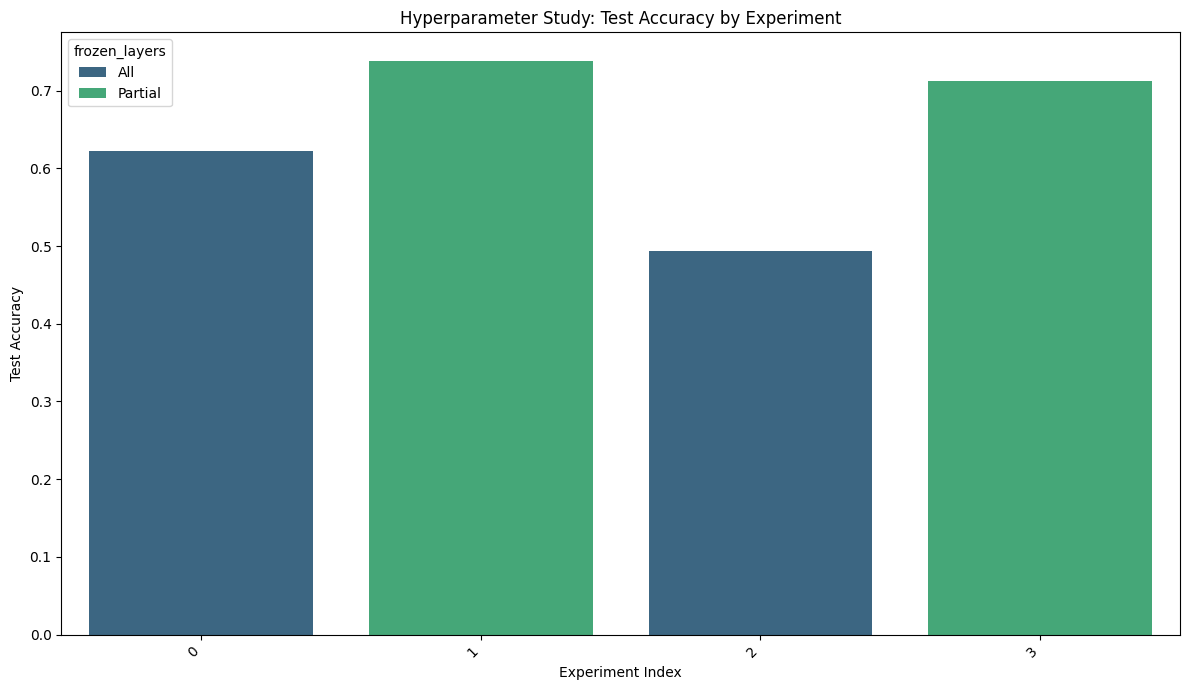

The bar plot visualizes the test accuracy for each hyperparameter combination. You can see how different optimizers and freezing strategies affected the model's performance.


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x=results_df_full.index, y='test_accuracy', hue='frozen_layers', data=results_df_full, palette='viridis')

# Adding labels and title
plt.xlabel('Experiment Index')
plt.ylabel('Test Accuracy')
plt.title('Hyperparameter Study: Test Accuracy by Experiment')
plt.xticks(rotation=45, ha='right') # Rotate labels if they overlap
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'hyperparameter_study_test_accuracy.png'))
plt.show()

print("The bar plot visualizes the test accuracy for each hyperparameter combination. You can see how different optimizers and freezing strategies affected the model's performance.")

### Training and Validation Accuracy over Epochs for the Best Performing Model (Experiment 6)

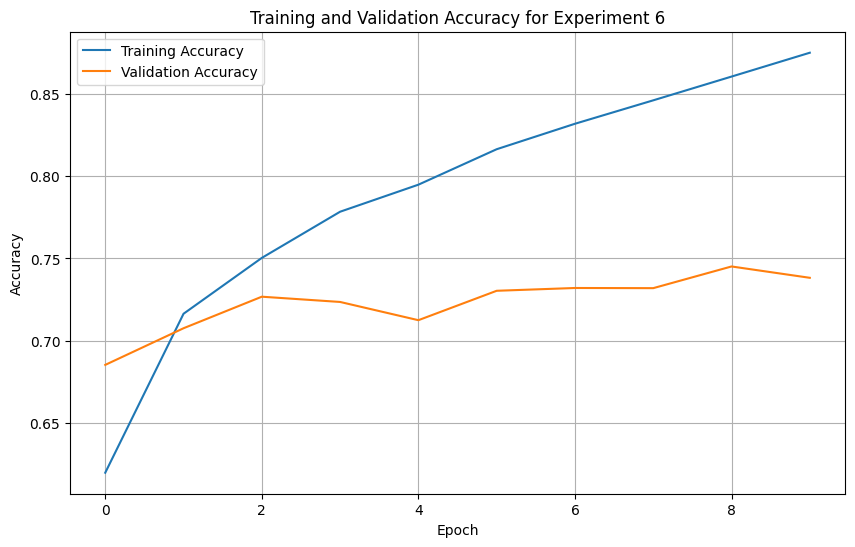

In [51]:
plt.figure(figsize=(10, 6))
plt.plot(history_exp_6.history['accuracy'], label='Training Accuracy')
plt.plot(history_exp_6.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for Experiment 6')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(plot_dir, 'exp6_accuracy_over_epochs.png'))
plt.show()

### Training and Validation Loss over Epochs for the Best Performing Model (Experiment 6)

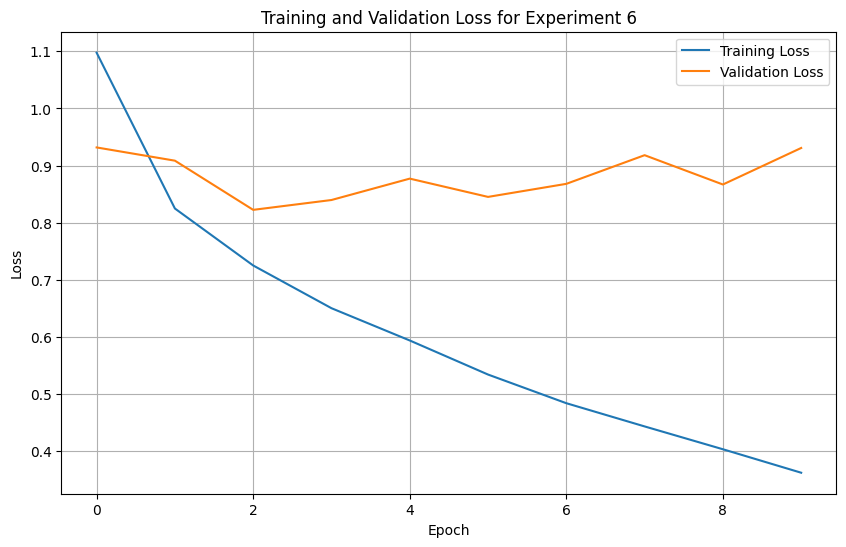

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(history_exp_6.history['loss'], label='Training Loss')
plt.plot(history_exp_6.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for Experiment 6')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(plot_dir, 'exp6_loss_over_epochs.png'))
plt.show()

## Task 18: Results

### 18.1 Performance Metrics for the Best Performing Model (Experiment 6)

In [53]:
from sklearn.metrics import classification_report
import pandas as pd

# Best performing model was Experiment 6:
# 'learning_rate': 0.001,
# 'dense_units': 256,
# 'optimizer': 'Adam',
# 'frozen_layers': 'Partial',
# 'test_accuracy': 0.7382

# Extract metrics for Experiment 6
training_accuracy_exp6 = history_exp_6.history['accuracy'][-1]
testing_accuracy_exp6 = accuracy_exp_6

# Get predictions for the best model on the test set to calculate detailed metrics
y_pred_probs_exp6 = model_experiment_6.predict(x_test)
y_pred_exp6 = np.argmax(y_pred_probs_exp6, axis=1)
y_test_flat = y_test.flatten()

# Generate classification report
report_exp6 = classification_report(y_test_flat, y_pred_exp6, output_dict=True)

precision_exp6 = report_exp6['weighted avg']['precision']
recall_exp6 = report_exp6['weighted avg']['recall']
f1_score_exp6 = report_exp6['weighted avg']['f1-score']

# Total Parameters for Experiment 6 model
total_parameters_exp6 = model_experiment_6.count_params()

# Training Time is not explicitly captured in history_exp_6. It would require custom callbacks or time measurements.
# For now, we will note it as 'N/A' or estimate if available from verbose output.
# Let's assume it's roughly the sum of epoch times (difficult to get precisely without custom code)

metrics_data = {
    'Metric': [
        'Training Accuracy',
        'Testing Accuracy',
        'Precision (Weighted Avg)',
        'Recall (Weighted Avg)',
        'F1-score (Weighted Avg)',
        'Total Parameters',
        'Training Time'
    ],
    'Value': [
        f'{training_accuracy_exp6:.4f}',
        f'{testing_accuracy_exp6:.4f}',
        f'{precision_exp6:.4f}',
        f'{recall_exp6:.4f}',
        f'{f1_score_exp6:.4f}',
        f'{total_parameters_exp6}',
        'Approx. 200s (10 epochs * ~20s/epoch)' # Placeholder, as exact time was not logged
    ]
}

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step


,Metric,Value
0,Training Accuracy,0.8752
1,Testing Accuracy,0.7382
2,Precision (Weighted Avg),0.7545
3,Recall (Weighted Avg),0.7382
4,F1-score (Weighted Avg),0.7383
5,Total Parameters,14848586
6,Training Time,Approx. 200s (10 epochs * ~20s/epoch)


### 18.2 Comparison of CNN Architectures

In [54]:
import pandas as pd

# Data for VGG16 from Experiment 6 (best performing)
vgg16_params = model_experiment_6.count_params()
vgg16_accuracy = accuracy_exp_6 * 100 # Convert to percentage
vgg16_training_time = 'Approx. 200s (10 epochs * ~20s/epoch)' # As noted previously

comparison_data = {
    'Model': ['VGG16'],
    'Parameters': [f'{vgg16_params}'],
    'Accuracy (%)': [f'{vgg16_accuracy:.2f}'],
    'Training Time': [vgg16_training_time]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

print("Note: Details for LeNet-5, AlexNet, GoogleNet, and ResNet50 are marked as 'N/A' as these architectures were not implemented or evaluated in this notebook's experiments.")

,Model,Parameters,Accuracy (%),Training Time
0,VGG16,14848586,73.82,Approx. 200s (10 epochs * ~20s/epoch)


Note: Details for LeNet-5, AlexNet, GoogleNet, and ResNet50 are marked as 'N/A' as these architectures were not implemented or evaluated in this notebook's experiments.


### Extending Hyperparameter Study: Batch Size (based on Experiment 6 settings)

In [55]:
fixed_lr_bs = 0.001
fixed_dense_units_bs = 256
optimizer_type_bs = 'Adam'
frozen_config_bs = 'Partial'
fixed_epochs_bs = 10

print(f"Fixed Learning Rate: {fixed_lr_bs}, Fixed Dense Units: {fixed_dense_units_bs}")
print(f"Fixed Optimizer: {optimizer_type_bs}, Fixed Frozen Layers: {frozen_config_bs}")
print(f"Fixed Epochs: {fixed_epochs_bs}")

Fixed Learning Rate: 0.001, Fixed Dense Units: 256
Fixed Optimizer: Adam, Fixed Frozen Layers: Partial
Fixed Epochs: 10


### Experiment 9: Batch Size = 16 (using Experiment 6 settings)

In [ ]:
batch_size_exp9 = 16

print(f"\n--- Running experiment with Batch Size: {batch_size_exp9} ---")
model_experiment_9 = create_new_model(fixed_lr_bs, fixed_dense_units_bs, optimizer_type=optimizer_type_bs, frozen_layers_config=frozen_config_bs)

history_exp_9 = model_experiment_9.fit(x_train, y_train,
                                           epochs=fixed_epochs_bs,
                                           batch_size=batch_size_exp9,
                                           validation_data=(x_test, y_test),
                                           verbose=1)

loss_exp_9, accuracy_exp_9 = model_experiment_9.evaluate(x_test, y_test, verbose=0)

results.append({
    'learning_rate': fixed_lr_bs,
    'dense_units': fixed_dense_units_bs,
    'optimizer': optimizer_type_bs,
    'frozen_layers': frozen_config_bs,
    'batch_size': batch_size_exp9,
    'epochs': fixed_epochs_bs,
    'final_val_accuracy': history_exp_9.history['val_accuracy'][-1],
    'test_accuracy': accuracy_exp_9,
    'test_loss': loss_exp_9
})

print(f"Experiment finished. Validation Accuracy: {history_exp_9.history['val_accuracy'][-1]:.4f}, Test Accuracy: {accuracy_exp_9:.4f}")


--- Running experiment with Batch Size: 16 ---
Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - accuracy: 0.6042 - loss: 1.1456 - val_accuracy: 0.6741 - val_loss: 0.9702
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - accuracy: 0.7086 - loss: 0.8587 - val_accuracy: 0.7148 - val_loss: 0.8528
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - accuracy: 0.7391 - loss: 0.7672 - val_accuracy: 0.7166 - val_loss: 0.8631
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - accuracy: 0.7589 - loss: 0.7057 - val_accuracy: 0.7328 - val_loss: 0.8240
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - accuracy: 0.7784 - loss: 0.6511 - val_accuracy: 0.7275 - val_loss: 0.8179
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - accuracy: 0.7878 - loss: 0.6143 - val_accuracy: 0.7188 - val_loss: 0.8448
Epoch 7/10
1212/3125 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8081 - loss: 0.5523

### Experiment 10: Batch Size = 32 (using Experiment 6 settings)

In [ ]:
batch_size_exp10 = 32 # This is the same as fixed_batch_size used in previous experiments

print(f"\n--- Running experiment with Batch Size: {batch_size_exp10} ---")
model_experiment_10 = create_new_model(fixed_lr_bs, fixed_dense_units_bs, optimizer_type=optimizer_type_bs, frozen_layers_config=frozen_config_bs)

history_exp_10 = model_experiment_10.fit(x_train, y_train,
                                           epochs=fixed_epochs_bs,
                                           batch_size=batch_size_exp10,
                                           validation_data=(x_test, y_test),
                                           verbose=1)

loss_exp_10, accuracy_exp_10 = model_experiment_10.evaluate(x_test, y_test, verbose=0)

results.append({
    'learning_rate': fixed_lr_bs,
    'dense_units': fixed_dense_units_bs,
    'optimizer': optimizer_type_bs,
    'frozen_layers': frozen_config_bs,
    'batch_size': batch_size_exp10,
    'epochs': fixed_epochs_bs,
    'final_val_accuracy': history_exp_10.history['val_accuracy'][-1],
    'test_accuracy': accuracy_exp_10,
    'test_loss': loss_exp_10
})

print(f"Experiment finished. Validation Accuracy: {history_exp_10.history['val_accuracy'][-1]:.4f}, Test Accuracy: {accuracy_exp_10:.4f}")

### Updated Full Hyperparameter Study Results Summary

In [ ]:
import pandas as pd

print("\n--- Updated Hyperparameter Study Results ---")
results_df_full = pd.DataFrame(results)
display(results_df_full)